In [21]:
%pip install gsw

import urllib.parse

import numpy  as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import gsw
%matplotlib inline

Go to [https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.html] to generate an ERDAP url.

In [22]:
#url = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.csv?fileNumber%2Ctime%2Clatitude%2Clongitude%2Cpres%2Cpres_adjusted%2Ctemp%2Ctemp_adjusted%2Cpsal%2Cpsal_adjusted%2Cdoxy%2Cturbidity%2Cchla%2Cnitrate&fileNumber=%223902687%22&latitude%3E=-20&latitude%3C=20&longitude%3E=-20&longitude%3C=20"


host = "https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.csv"
columns = "fileNumber%2Ctime%2Clatitude%2Clongitude%2Cpres%2Ctemp%2Cpsal%2Cdoxy%2Cturbidity%2Cchla%2Cnitrate"
values = {'fileNumber': '"3902687"',
          'latitude>':  -20,  'latitude<': 20,
          'longitude>': -20, 'longitude<': 20}
values = urllib.parse.urlencode(values)
"fileNumber=%223902687%22&latitude%3E=-20&latitude%3C=20&longitude%3E=-20&longitude%3C=20"
url = host + "?" + columns + "&" + values
#urllib.parse.urljoin(url, columns, values)



In [23]:
df = pd.read_csv(url, skiprows=[1])

In [24]:
df

,fileNumber,time,latitude,longitude,pres,temp,psal,doxy,turbidity,chla,nitrate
0,3902687,2025-08-08T14:54:45Z,5.29053,0.18557,0.96,23.535,35.900,NaN,NaN,NaN,NaN
1,3902687,2025-08-08T14:54:45Z,5.29053,0.18557,2.00,23.511,35.895,NaN,NaN,NaN,NaN
2,3902687,2025-08-08T14:54:45Z,5.29053,0.18557,3.00,23.422,35.909,NaN,NaN,NaN,NaN
3,3902687,2025-08-08T14:54:45Z,5.29053,0.18557,4.00,23.280,35.912,NaN,NaN,NaN,NaN
4,3902687,2025-08-08T14:54:45Z,5.29053,0.18557,5.04,23.200,35.908,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
21416,3902687,2026-02-24T06:36:50Z,3.43095,3.14590,1996.04,3.554,34.961,NaN,NaN,NaN,NaN
21417,3902687,2026-02-24T06:36:50Z,3.43095,3.14590,1998.04,3.552,34.961,NaN,NaN,NaN,NaN
21418,3902687,2026-02-24T06:36:50Z,3.43095,3.14590,2000.08,3.548,34.961,NaN,NaN,NaN,NaN
21419,3902687,2026-02-24T06:36:50Z,3.43095,3.14590,2002.16,3.544,34.961,NaN,NaN,NaN,NaN


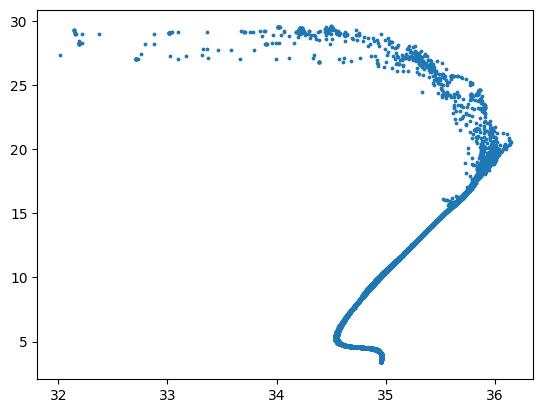

In [6]:
plt.scatter(df["psal"], df["temp"],3)

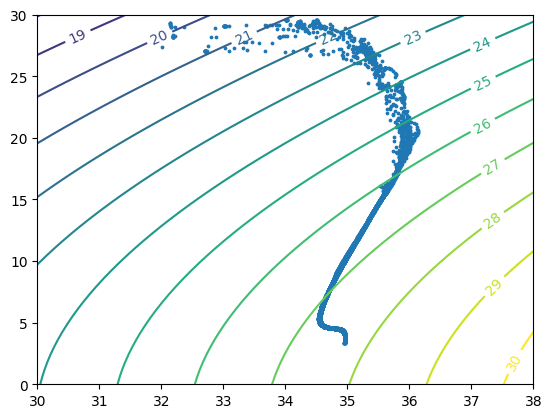

In [20]:

salt = np.linspace(30,38,50)
temp = np.linspace(0,30, 50)
salt,temp = np.meshgrid(salt, temp)

sigma0 = gsw.sigma0(salt, temp)  # reference pressure = 0 dbar
cp = plt.contour(salt,temp, sigma0, range(17,31))
plt.clabel(cp, inline=True, fontsize=10)
plt.scatter(df["psal"], df["temp"],3)